<h1 style="color:green;font-size:22px;">Function 1 - Black-Box Optimisation</h1>
<h1 style="color:#0000CD;font-size:19px;"">Introduction and illustrative analogy</h1>

**Function 1** is a two-dimensional black-box objective over the bounded domain $[0,1]^2$. Its analytical form and physical interpretation are unknown. The objective is to identify high-value input configurations under a limited sequential-query budget.

As an illustrative analogy, imagine searching a two-dimensional area for small hidden contamination sources with a detector, where readings may change only near a source. Bayesian optimisation uses each observation to decide where to search next, balancing unexplored areas with promising locations.

The goal is to maximise **Function 1**.

In [43]:
# Standard libraries
import sys
import warnings
import numpy as np
from pathlib import Path

# Scikit-learn for surrogate functions 
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

# BBO Project Root 
ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))
    
# BBO Project package
from src.config import RANDOM_SEED
from src.data import load_initial_data, extract, update_data
from src.search import distance_to_n_closest_point, cartesian_grid, search_region, random_candidates
from src.acquisition import upper_confidence_bound, expected_improvement, probability_of_improvement
from src.plotting import plot_data_exploration, plot_acquisition_2d, plot_rbf_surface_3d, plot_global_to_local_refinement_2d

FUNCTION_ID = 1

warnings.filterwarnings("ignore", category=ConvergenceWarning)

<h1 style="color:#0000CD;font-size:19px;"">Week 1</h1>

**1.1 - Extraction of Initial Data**

In [44]:
data = load_initial_data(FUNCTION_ID)
display(data)

,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


In [45]:
inputs, outputs = extract(data)
print(inputs.shape, outputs.shape)

(10, 2) (10,)


**1.2 - Geometric exploration of intuitive candidates**

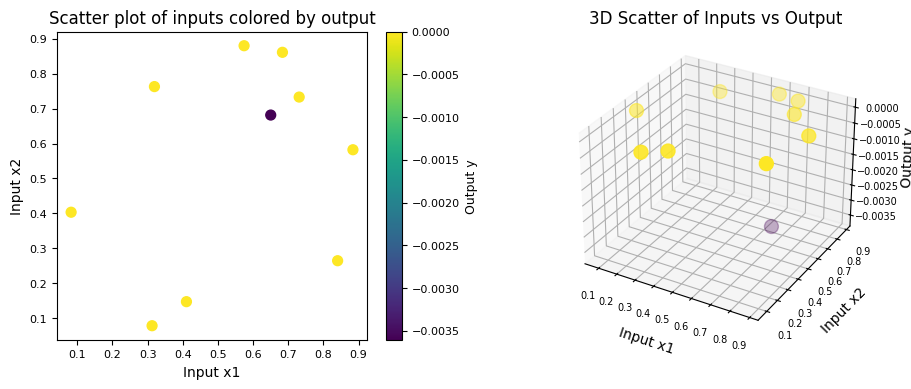

In [46]:
plot_data_exploration(data)

**Observations:**
- \$ (x_1, x_2) \in [0, 1]^2\$
- One initial observation point (0.650114, 0.681526) has its output (-3.606063e-03)  significantly lower than the other points. Otherwise other remaining points have magnitudes close to zero.
- The observed maximum (0.731024, 0.733000) is also practically ~0 (7.7e-16).

**Interpretation:**
- Most of the initially sampled locations returned responses numerically close to zero. However, the limited initial design does not establish whether the unsampled domain is globally flat or contains narrow localised features.
- There is no obvious strong positive peak yet.
- The sparse initial design does not establish that the unsampled domain is flat or that the substantially negative observation belongs to an extended valley.
- Early rounds therefore prioritise exploration of poorly sampled locations rather than local exploitation of the incumbent.

**Geometric Exploration:**
- A small set of intuitive candidate locations is first considered: the four corners (0,0), (0,1), (1,1), (1,0) and the centre of the domain (0.5,0.5). These points are compared using their distances from the nearest existing observations. This provides a simple, interpretable exploration benchmark before extending the same distance-based principle to a full candidate grid. Among the intuitive candidates, (0,0) is furthest from the substantially negative observation (0.650114, 0.681526). However, under the maximin nearest-neighbour criterion, (0,1) is the least-covered candidate and is therefore preferred for geometric exploration.

In [47]:
query_points = [(0,0), (0,1), (1,0), (1,1), (0.5,0.5)]
nb_points = [1,3,5]

for n in nb_points:
    print("Distances From ",n, "closest point(s):")
    for x,y in query_points:
        print((x,y),":",distance_to_n_closest_point(x,y,n, inputs))
    print('\n')

Distances From  1 closest point(s):
(0, 0) : 0.3224485002380642
(0, 1) : 0.39775256435676853
(1, 0) : 0.30914375125905713
(1, 1) : 0.34572978467882404
(0.5, 0.5) : 0.2355547652703174


Distances From  3 closest point(s):
(0, 0) : 1.1704400694534556
(0, 1) : 1.58669657672784
(1, 0) : 1.5106091039867398
(1, 1) : 1.1583069308187186
(0.5, 0.5) : 0.8826743985358633


Distances From  5 closest point(s):
(0, 0) : 2.878624733460741
(0, 1) : 3.0080250027399114
(1, 0) : 2.9685045257995712
(1, 1) : 2.073719799745944
(0.5, 0.5) : 1.633423145006783




Using the maximum distance to closest points, Geometric Exploration suggests to query next (0,1).

**1.3 - Grid-based distance exploration**

In [48]:
# Candidate points (grid)
X_grid = cartesian_grid(dimension=2,points_per_axis=50) 

# Compute min distance from each candidate to existing points
distances = np.min(np.linalg.norm(X_grid[:,None,:] - inputs[None,:,:], axis=2), axis=1)

# Select candidate with largest min distance (furthest from existing points)
next_idx = np.argmax(distances)
next_point = X_grid[next_idx]
print(f"Next point (furthest from existing points):{next_point[0]:.3f}-{next_point[1]:.3f}")

Next point (furthest from existing points):0.000-1.000


**1.4 - Bayesian Optimisation using Gaussian Process + Upper Confidence Bound**

**Numerical Scale Consideration:** The observed outputs span an exceptionally wide numerical range. The negative observation therefore dominates the variance of the raw target, while the extremely small positive observations may be difficult for the global Gaussian Process to distinguish. The initial GP should consequently be interpreted primarily as a broad exploration model rather than as a precise ranking of near-zero observations.

In [49]:
# Gaussian Process Surrogate with RBF Kernel
kernel = RBF(length_scale=0.2, length_scale_bounds="fixed") + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
mu, sigma = gp.predict(X_grid, return_std=True)

# Upper Confidence Bound Acquisition
ucb = upper_confidence_bound(mu, sigma, kappa=1.5)
index_max = np.argmax(ucb)
next_point = np.array(X_grid[index_max], float)
print(f"Next point (with GP + UCB):{next_point[0]:.6f}-{next_point[1]:.6f}")

Next point (with GP + UCB):0.877551-1.000000


Given the observed responses from **Function 1** are generally close to ~0 except 1 point, we focus on exploration rather than exploitation. 

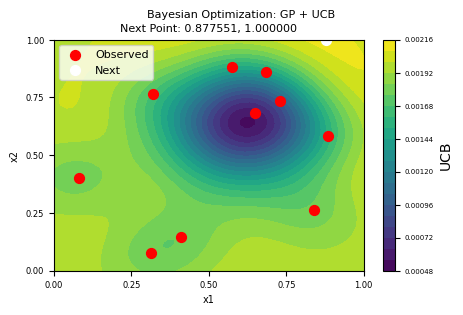

In [50]:
plot_acquisition_2d(X_grid, ucb, data, next_point, "UCB")

**1.5 - Comparison of Geometric vs GP-UCB candidates**

In [51]:
# Acquisition Comparison (UCB) forGeometric Vs Bayesian Optimisation
point = np.array([0, 1])
idx = np.where(np.all(np.isclose(X_grid, point), axis=1))[0][0]
print(f"UCB at geometric candidate [0, 1]: {ucb[idx]:.6f}")
print(f"Maximum UCB over the grid: {ucb[index_max]:.6f}")

UCB at geometric candidate [0, 1]: 0.001959
Maximum UCB over the grid: 0.002101


In the GP + UCB framework, the acquisition function suggests a more interesting point to explore as (0.877551,1.000000)

<h1 style="color:#0000CD;font-size:19px;"">Week 2</h1>

**2.1 - Previous Week's Query Result**

In [52]:
# New Query Point
x_new = np.array([0.877551, 1.000000])
y_new = 1.2259935799032287e-139

data = update_data(data, x_new, y_new)
inputs, outputs = extract(data)
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


**2.2 - Next Point Query**

In [53]:
# Gaussian Process Surrogate
kernel = RBF(length_scale=0.2, length_scale_bounds="fixed") + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
mu, sigma = gp.predict(X_grid, return_std=True)

# Upper Confidence Bound Acquisition
ucb = upper_confidence_bound(mu, sigma, kappa=1.5)
index_max = np.argmax(ucb)
next_point = np.array(X_grid[index_max], float)
print(f"Next point (with GP + UCB):{next_point[0]:.6f}-{next_point[1]:.6f}")

Next point (with GP + UCB):0.326531-1.000000


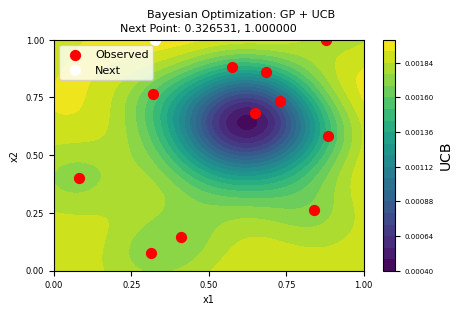

In [54]:
plot_acquisition_2d(X_grid, ucb, data, next_point, "UCB")

<h1 style="color:#0000CD;font-size:19px;"">Week 3</h1>

**3.1 - Previous Week's Query Result**

In [55]:
# New Query Point
x_new = np.array([0.326531, 1.000000])
y_new = -6.43315543369651e-160

data = update_data(data, x_new, y_new)
inputs, outputs = extract(data)
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


**3.2 - Next Point Query**

The first two UCB queries did not improve the incumbent. The exploration parameter $\kappa$ is therefore increased from 1.5 to 2.0, placing slightly more weight on posterior uncertainty while maintaining a global search strategy.

In [56]:
# Gaussian Process Surrogate
kernel = RBF(length_scale=0.2, length_scale_bounds="fixed") + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
mu, sigma = gp.predict(X_grid, return_std=True)

# Upper Confidence Bound Acquisition
ucb = upper_confidence_bound(mu, sigma, kappa=2)
next_point = np.array(X_grid[np.argmax(ucb)], float)
print(f"Next point (with GP + UCB):{next_point[0]:.6f}-{next_point[1]:.6f}")

Next point (with GP + UCB):0.020408-0.775510


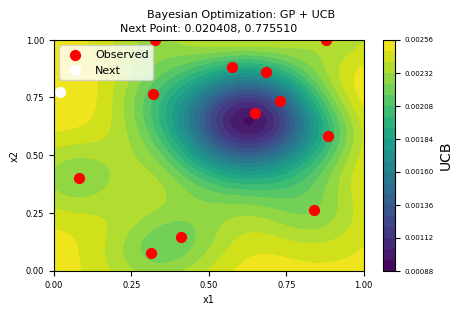

In [57]:
plot_acquisition_2d(X_grid, ucb, data, next_point, "UCB")

<h1 style="color:#0000CD;font-size:19px;"">Week 4</h1>

**4.1 - Previous Week's Query Result**

In [58]:
# New Query Point
x_new = np.array([0.020408, 0.775510])
y_new = 3.1776222232122792e-201

data = update_data(data, x_new, y_new)
inputs, outputs = extract(data)
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


The first three sequential queries also returned values numerically close to zero. This provides no evidence of a broad positive region, but it does not rule out narrow local structure. For one further exploration-oriented UCB query, κ is increased from 2.0 to 2.25.

**4.2 - Next Point Query**

In [59]:
# Gaussian Process Surrogate
kernel = RBF(length_scale=0.2, length_scale_bounds="fixed") + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
mu, sigma = gp.predict(X_grid, return_std=True)

# Upper Confidence Bound Acquisition
ucb=upper_confidence_bound(mu, sigma, kappa=2.25)
next_point = np.array(X_grid[np.argmax(ucb)], float)
print(f"Next point (with GP + UCB):{next_point[0]:.6f}-{next_point[1]:.6f}")

Next point (with GP + UCB):0.693878-0.000000


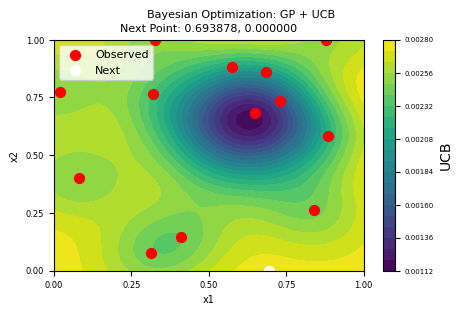

In [60]:
plot_acquisition_2d(X_grid, ucb, data, next_point, "UCB")

<h1 style="color:#0000CD;font-size:19px;"">Week 5</h1>

**5.1 - Previous Week's Query Result**

In [61]:
# New Query Point
x_new = np.array([0.693878, 0.000000])
y_new = 4.060743331513648e-177

data = update_data(data, x_new, y_new)
inputs, outputs = extract(data)
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


**5.2 - Diagnostics following results**
 
- None of the first four sequential queries improved the initial incumbent. Most observed responses remain numerically close to zero, while one interior observation is substantially negative.
- This creates a boundary bias: UCB explores where uncertainty is highest (at the boundaries because mean is ~0 and flat).
- Let's shift the optimisation problem from exploring the domain to find the best region using EI: we reduce the emphasis on uncertainty-driven exploration by replacing UCB with Expected Improvement. At the same time, the RBF length scale is allowed to adapt to the observed data rather than remaining fixed at 0.2.

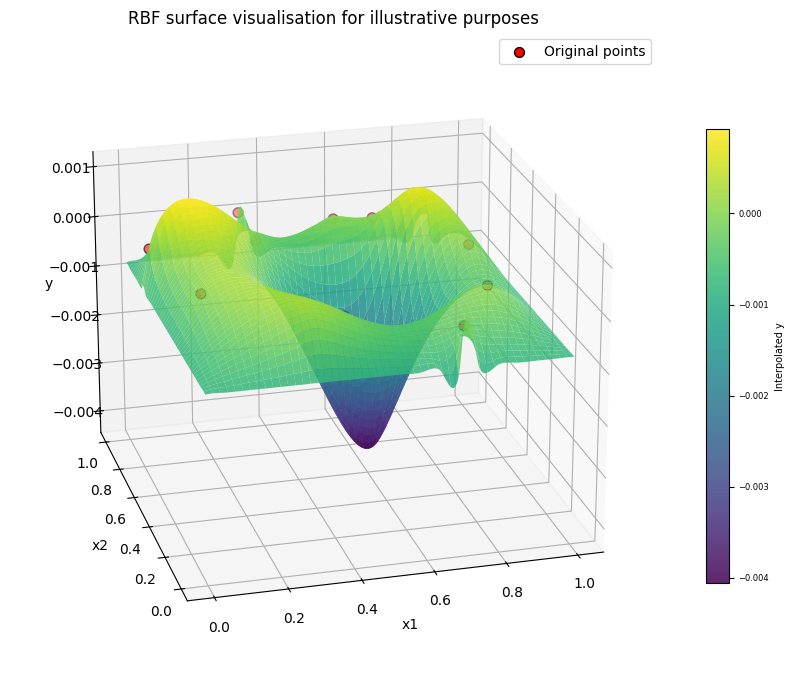

In [62]:
plot_rbf_surface_3d(data)

**Exploratory RBF Visualisation:** To support qualitative interpretation of the sparse observations, an RBF interpolator is fitted using the observed points together with artificial boundary anchors assigned a value of (-8\times10^{-4}). These boundary anchors are introduced solely to regularise the visualisation and prevent unconstrained behaviour near the edges of the domain.

Under this specific boundary assumption, the interpolated surface displays two comparatively elevated areas: [0.05,0.30]x[0.70,0.95] and [0.70,0.95]x[0.70,0.95]. These are qualitative hypothesis regions whose shape depends on the boundary assumptions. They do not determine candidate selection, which remains driven by the GP acquisition function fitted to observed data.

**5.3 - Next point query (Switch to EI)**

In [63]:
# Increase the resolution of Candidate points to 500x500 (grid)
X_grid = cartesian_grid(2,500)

# Gaussian Process Surrogate
kernel = RBF(length_scale=0.2, length_scale_bounds=(0.05,1.0))+ WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
mu, sigma = gp.predict(X_grid, return_std=True)

# Expected Improvement Acquisition
f_best = np.max(outputs)
ei = expected_improvement(mu, sigma, f_best)
next_point = X_grid[np.argmax(ei)]
print(f"Next point (with GP + EI): {next_point[0]:.6f}-{next_point[1]:.6f}")

Next point (with GP + EI): 0.765531-0.763527


***Note on Kernel Length-scale bound hyperparameter:*** *The RBF length scale is constrained to a minimum of 0.05 on the normalised [0,1] domain. This acts as a regularisation constraint, allowing local variation while preventing the GP from fitting arbitrarily short-scale structure. The constraint is retained deliberately to favour a smoother surrogate for Bayesian optimisation.*

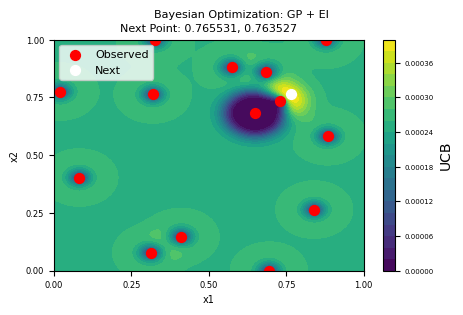

In [64]:
plot_acquisition_2d(X_grid, ei, data, next_point, "EI")

<h1 style="color:#0000CD;font-size:19px;"">Week 6</h1>

**6.1 - Previous Week's Query Result**

In [65]:
# Queried Point result
x_new = np.array([0.765531, 0.763527])
y_new = 1.749055452140406e-26

data = update_data(data, x_new, y_new)
inputs, outputs = extract(data)
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


**6.2 - Next point query (EI)**

In [66]:
# Gaussian Process Surrogate
kernel = RBF(length_scale=0.2, length_scale_bounds=(0.05,1.0))+ WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
mu, sigma = gp.predict(X_grid, return_std=True)

# Expected Improvement Acquisition
ei = expected_improvement(mu, sigma, np.max(outputs))
next_point = X_grid[np.argmax(ei)]
print(f"Next point (with GP + EI): {next_point[0]:.6f}-{next_point[1]:.6f}")

Next point (with GP + EI): 0.783567-0.699399


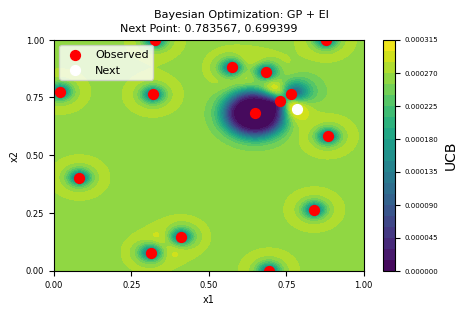

In [67]:
plot_acquisition_2d(X_grid, ei, data, next_point, "EI")

<h1 style="color:#0000CD;font-size:19px;"">Week 7</h1>

**7.1 - Previous Week's Query Result**

In [68]:
# Queried Point result
x_new = np.array([0.783567, 0.699399])
y_new = -1.2292415209893468e-20

data = update_data(data, x_new, y_new)
inputs, outputs = extract(data)
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


**7.2 - Next point query (EI)**

In [69]:
# Gaussian Process Surrogate
kernel = RBF(length_scale=0.2, length_scale_bounds=(0.05,1.0))+ WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
mu, sigma = gp.predict(X_grid, return_std=True)

# Expected Improvement Acquisition
ei = expected_improvement(mu, sigma, np.max(outputs))
next_point = X_grid[np.argmax(ei)]
print(f"Next point (with GP + EI): {next_point[0]:.6f}-{next_point[1]:.6f}")

Next point (with GP + EI): 0.330661-0.156313


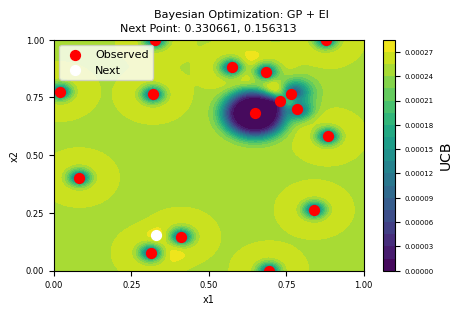

In [70]:
plot_acquisition_2d(X_grid, ei, data, next_point, "EI")

<h1 style="color:#0000CD;font-size:19px;"">Week 8</h1>

**8.1 - Previous Week's Query Result**

In [71]:
# Queried Point result
x_new = np.array([0.330661, 0.156313])
y_new = 8.806551116051378e-56

data = update_data(data, x_new, y_new)
inputs, outputs = extract(data)
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


**8.2 - Next point query (EI)**

In [72]:
# Gaussian Process Surrogate
kernel = RBF(length_scale=0.2, length_scale_bounds=(0.05,1.0))+ WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
mu, sigma = gp.predict(X_grid, return_std=True)

# Expected Improvement Acquisition
ei = expected_improvement(mu, sigma, np.max(outputs))
next_point = X_grid[np.argmax(ei)]
print(f"Next point (with GP + EI): {next_point[0]:.6f}-{next_point[1]:.6f}")

Next point (with GP + EI): 0.639279-0.929860


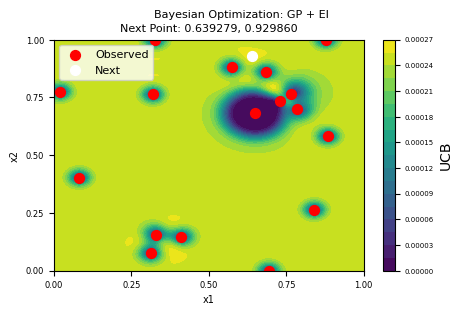

In [73]:
plot_acquisition_2d(X_grid, ei, data, next_point, "EI")

<h1 style="color:#0000CD;font-size:19px;"">Week 9</h1>

**9.1 - Previous Week's Query Result**

In [74]:
# Queried Point result
x_new = np.array([0.639279, 0.929860])
y_new = 1.070313432884962e-63

data = update_data(data, x_new, y_new)
inputs, outputs = extract(data)
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


**9.2 - Observations after 8 weeks**

- All previous wide EI/UCB style points queried produced values close to zero or much worse than the current best [0.731024, 0.733000] → 7.710875e-16
- The only substantially adverse observation is [0.650114, 0.681526] → -0.003606063.
- The point [0.765531, 0.763527] already improved compared with most exploratory points, but it was still far worse than the current best.

**Conclusions**

The observations are consistent with a highly localised positive region around [0.731024, 0.733000],although the precise local geometry remains uncertain. Most observed outputs are concentrated close to zero, while the single substantially negative observation at [0.650114, 0.681526] dominates the overall output range. <br>

Given that 5  queries remain, the search will move from global exploration to local refinement (**local PI**). Probability of Improvement will be maximised within a small trust region around the current incumbent, using a shorter-length-scale and less smooth GP kernel. Because the surrogate remains fitted to all observations, the PI values are used primarily to rank candidate points within the local region rather than interpreted as precisely calibrated probabilities.

With that objective in mind, we will:

- restrict PI to a smaller region around the incumbent [0.731024, 0.733000]
- use a shorter-length-scale GP and a rougher kernel.


**9.3 - Next point query (Switch to Local PI)**

In [75]:
# Local PI configuration
x_best = inputs[np.argmax(outputs)]
y_best = np.max(outputs)
radius = 0.005                        # tight trust region around current best
xi = 0.0                              # no additional improvement margin
n_candidates = 50_000                 # random local candidate search

# Local candidate search in search trust region
lower, upper = search_region(x_best, radius)
X_cand = random_candidates(inputs.shape[1], n_candidates, lower, upper)

# Short-lengthscale GP for narrow spike
kernel = ConstantKernel(1.0, (1e-6, 1e6)) * Matern(length_scale=np.array([0.0025, 0.0025]),length_scale_bounds=(1e-4, 0.05),nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel,alpha=1e-12,normalize_y=True,n_restarts_optimizer=20,random_state=RANDOM_SEED)
gp.fit(inputs, outputs)

# Probability of Improvement Acquisition
mu, sigma = gp.predict(X_cand, return_std=True)
pi = probability_of_improvement(mu, sigma, y_best, xi)
next_point = X_cand[np.argmax(pi)]
print(f"Next point (with GP + PI): {next_point[0]:.6f}-{next_point[1]:.6f}")

Next point (with GP + PI): 0.731124-0.733063


**9.4 - Visualising the Transition from Global EI to Local PI**

In [76]:
# Local Grid for the Zoomed contour 
X_local_grid = cartesian_grid(dimension=2,points_per_axis=300,lower=lower,upper=upper)
mu_local, sigma_local = gp.predict(X_local_grid, return_std=True)
grid_size = int(np.sqrt(len(X_local_grid)))
mu_surface = mu_local.reshape(grid_size,grid_size)

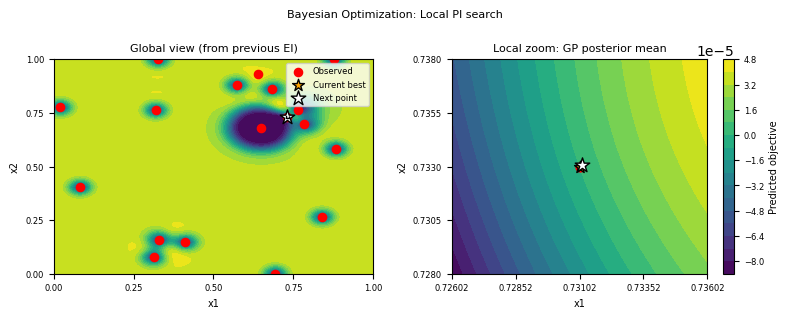

In [77]:
# Visualisation 
plot_global_to_local_refinement_2d(X_grid, ei, X_local_grid, mu_surface, data, lower, upper, next_point) 

<h1 style="color:#0000CD;font-size:19px;"">Week 10</h1>

**10.1 - Previous Week's Query Result**

In [78]:
# Queried Point result
x_new = np.array([0.731124, 0.733063])
y_new = 7.232455306377106e-16

data = update_data(data, x_new, y_new)
inputs, outputs = extract(data)
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


**10.2 - Next point query (Local PI)**
    
- The first Local PI query produced the strongest sequentially queried result so far, although it remained below the initial incumbent. The trust-region radius is increased from 0.005 to 0.01 to test whether improvement may lie slightly farther from the incumbent.

In [79]:
# Local PI configuration
x_best = inputs[np.argmax(outputs)]
y_best = np.max(outputs)
radius = 0.01                         # tight trust region around current best
xi = 0.0                              # no additional improvement margin
n_candidates = 50_000                 # random local candidate search

# Random candidates inside Trust region
lower, upper = search_region(x_best, radius)
X_cand = random_candidates(inputs.shape[1], n_candidates, lower, upper)

# Short-lengthscale GP for narrow spike
kernel = ConstantKernel(1.0, (1e-6, 1e6)) * Matern(length_scale=np.array([0.0025, 0.0025]),length_scale_bounds=(1e-4, 0.05),nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel,alpha=1e-12,normalize_y=True,n_restarts_optimizer=20,random_state=RANDOM_SEED)
gp.fit(inputs, outputs)

# Probability of Improvement Acquisition
mu, sigma = gp.predict(X_cand, return_std=True)
pi = probability_of_improvement(mu, sigma, y_best, xi)
next_point = X_cand[np.argmax(pi)]
print(f"Next point (with GP + PI): {next_point[0]:.6f}-{next_point[1]:.6f}")

Next point (with GP + PI): 0.740979-0.733546


<h1 style="color:#0000CD;font-size:19px;"">Week 11</h1>

**11.1 - Previous Week's Query Result**

In [80]:
# Queried Point result
x_new = np.array([0.740979, 0.733546])
y_new = 7.467654736306343e-18

data = update_data(data, x_new, y_new)
inputs, outputs = extract(data)
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


**11.2 - Next point query (Local PI)**
    
- The larger-radius query returned a substantially weaker value. The trust-region radius is therefore contracted to 0.001 around the incumbent.

In [81]:
# Local PI configuration
x_best = inputs[np.argmax(outputs)]
y_best = np.max(outputs)
radius = 0.001                        # tight trust region around current best
xi = 0.0                              # no additional improvement margin
n_candidates = 50_000                 # random local candidate search

# Random candidates inside Trust region
lower, upper = search_region(x_best, radius)
X_cand = random_candidates(inputs.shape[1], n_candidates, lower, upper)

# Short-lengthscale GP for narrow spike
kernel = ConstantKernel(1.0, (1e-6, 1e6)) * Matern(length_scale=np.array([0.0025, 0.0025]), length_scale_bounds=(1e-4, 0.05), nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-12, normalize_y=True, n_restarts_optimizer=20,random_state=RANDOM_SEED)
gp.fit(inputs, outputs)

# Probability of Improvement Acquisition
mu, sigma = gp.predict(X_cand, return_std=True)
pi = probability_of_improvement(mu, sigma, y_best, xi)
next_point = X_cand[np.argmax(pi)]

print(f"Next point (with GP + PI): {next_point[0]:.6f}-{next_point[1]:.6f}")

Next point (with GP + PI): 0.731051-0.733016


<h1 style="color:#0000CD;font-size:19px;"">Week 12</h1>

**12.1 - Previous Week's Query Result**

In [82]:
# Queried Point result
x_new = np.array([0.731051, 0.733016])
y_new = 7.515668783384148e-16

data = update_data(data, x_new, y_new)
inputs, outputs = extract(data)
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


**12.2 - Local Exploitation Refinement**

The Local PI queries have identified nearby high-value points but have not improved the incumbent. With two evaluations remaining, the search switches from model-based PI to deterministic directional probes around the incumbent. The next probe is [0.731010,0.732975].


<h1 style="color:#0000CD;font-size:19px;"">Week 13</h1>

**13.1 - Previous Week's Query Result**

In [83]:
# Queried Point result
x_new = np.array([0.731010, 0.732975])
y_new = 7.829289359620921e-16

data = update_data(data, x_new, y_new)
inputs, outputs = extract(data)
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


**13.2 - Local Exploitation Refinement**

The latest point [0.731010, 0.732975] → 7.829289e-16, is slightly better than the original [0.731024, 0.733000] → 7.710875e-16 and better than the nearby north east probes. The nearby probes suggest slightly higher observed values toward the south-west, although the differences are small. A second south-west probe, [0.730950,0.732920], is submitted to test whether this directional improvement persists.

<h1 style="color:#0000CD;font-size:19px;"">Final Results</h1>

In [84]:
# Queried Point result
x_new = np.array([0.730950, 0.732920])
y_new = 8.190853877855047e-16

data = update_data(data, x_new, y_new)
inputs, outputs = extract(data)
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


The experiment began with 10 initial observations and added 13 sequentially selected queries:

- Initial best: [0.731024,0.733000] with y=7.710875×10−16
- Final best: [0.730950,0.732920] with y=8.190854×10−16
- Absolute improvement: 4.799788×10−17
- Relative improvement over the initial incumbent: ~6.22%

The global UCB and EI phases improved domain coverage but did not outperform the initial incumbent. The improvement was obtained during the final local directional-refinement phase. Given the sparse evaluation budget and the exceptionally small objective scale near the incumbent, the final point should be interpreted as the best observed configuration, not as proof of the global maximum.